In [3]:
import EOSutils as meos

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
from mpl_toolkits.axes_grid1 import make_axes_locatable

mpl.style.use('classic')

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

import mesa_helper as mh
import os
import shutil
import copy

from scipy import interpolate
from scipy.linalg import lstsq as scipy_lstsq
from scipy.ndimage import gaussian_filter
import scipy.integrate as integrate
import decimal 

%matplotlib inline

In [4]:
def spline3_naturalBC(x, node_x, node_y):

    a0 = node_y[0]
    a1 = node_y[1]
    a2 = node_y[2]

    x0 = node_x[0]
    x1 = node_x[1]
    x2 = node_x[2]
    
    h0 = x1 - x0
    h1 = x2 - x1

    c0 = 0.
    c1 = (3./(2*(h0+h1))) * ( ((a2 - a1)/h1) - ((a1-a0)/h0) )

    b0 = ((a1 - a0)/h0) - (1/3.)*h0*c1
    b1 = ((a2 - a1)/h1) - (2/3.)*h1*c1

    d0 = c1/(3.*h0)
    d1 = -1*(c1/(3.*h1))
    
    s_x = np.zeros_like(x)

    s0_mask = (x <= x1)
    s1_mask = (x > x1)

    s_x[s0_mask] = a0 + b0*(x[s0_mask] - x0) + c0*(x[s0_mask] - x0)**2  + d0*(x[s0_mask] - x0)**3 
    s_x[s1_mask] = a1 + b1*(x[s1_mask] - x1) + c1*(x[s1_mask] - x1)**2  + d1*(x[s1_mask] - x1)**3 
    return s_x

In [5]:
def spline3_noknotBC(x, node_x, node_y):

    a0 = node_y[0]
    a1 = node_y[1]
    a2 = node_y[2]

    x0 = node_x[0]
    x1 = node_x[1]
    x2 = node_x[2]
    
    h0 = x1 - x0
    h1 = x2 - x1
    
    #no knot BC in the n=2 case is just fitting one quadratic that goes through all 3 points
    d = 0.
    c = ( a2 - a1 + (h1/h0)*(a0-a1) + d*h0**3 + d*(h0**2 * h1) - d*(h0+h1)**3 )/(h1**2 + h0*h1)
    b = (a1 - a0)/h0 - c*h0 - d*h0**2

    s_x = a0 + b*(x-x0) + c*(x-x0)**2 + d*(x-x0)**3

    return s_x

In [6]:
test_x_3nodes = (3.,5.,7.)
test_y_3nodes = (1., -4., 12.)

test_x_3 = np.linspace(3.,7.,50)

'''
test_x_3nodes = (43., 151., 185.)
test_y_3nodes = (10., -52., 5.)

test_x_3 = np.linspace(43.,185.,50)
'''

test_y_3_natural = spline3_naturalBC(test_x_3,test_x_3nodes,test_y_3nodes)
test_y_3_noknot = spline3_noknotBC(test_x_3,test_x_3nodes,test_y_3nodes)

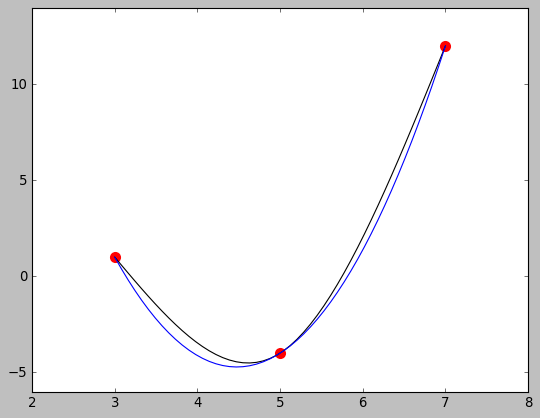

In [7]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(test_x_3nodes,test_y_3nodes,'ro',mec='None',ms=10)
ax.plot(test_x_3, test_y_3_natural, 'k-')
ax.plot(test_x_3, test_y_3_noknot, 'b-')
ax.set_xlim(2,8)
ax.set_ylim(-6,14)
plt.show()

In [8]:
def spline4_naturalBC(x, node_x, node_y):

    a0 = node_y[0]
    a1 = node_y[1]
    a2 = node_y[2]
    a3 = node_y[3]

    x0 = node_x[0]
    x1 = node_x[1]
    x2 = node_x[2]
    x3 = node_x[3]
    
    h0 = x1 - x0
    h1 = x2 - x1
    h2 = x3 - x2

    c0 = 0.
    c1 = (1./(2*(h0 + h1) - (h1/(h1 + (2/3.)*h2))*((2/3.)*h0 + h1))) * ( ((3*(a2-a1))/h1) - ((3*(a1-a0))/h0) - (h1/(h1 + (2/3.)*h2))*( (a3-a2)/h2 - (a1-a0)/h0 ))
    c2 = (1./(h1+(2/3.)*h2))*((a3-a2)/h2 - (a1-a0)/h0 - c1*((2/3.)*h0 + h1))

    b0 = (a1-a0)/h0 - (1/3.)*c1*h0
    b1 = b0 + c1*h0
    b2 = b1 + c1*h1 + c2*h1

    d0 = c1/(3.*h0)
    d1 = (c2 - c1)/(3.*h1)
    d2 = -1*(c2/(3.*h2))
    
    s_x = np.zeros_like(x)

    s0_mask = (x <= x1)
    s1_mask = (x > x1) & (x <= x2)
    s2_mask = (x > x2)

    s_x[s0_mask] = a0 + b0*(x[s0_mask] - x0) + c0*(x[s0_mask] - x0)**2  + d0*(x[s0_mask] - x0)**3 
    s_x[s1_mask] = a1 + b1*(x[s1_mask] - x1) + c1*(x[s1_mask] - x1)**2  + d1*(x[s1_mask] - x1)**3 
    s_x[s2_mask] = a2 + b2*(x[s2_mask] - x2) + c2*(x[s2_mask] - x2)**2  + d2*(x[s2_mask] - x2)**3 
    
    return s_x

In [9]:
def spline4_noknotBC(x, node_x, node_y):

    a0 = node_y[0]
    a1 = node_y[1]
    a2 = node_y[2]
    a3 = node_y[3]

    x0 = node_x[0]
    x1 = node_x[1]
    x2 = node_x[2]
    x3 = node_x[3]
    
    h0 = x1 - x0
    h1 = x2 - x1
    h2 = x3 - x2

    # no-knot BC in this case is fitting one cubic that goes through all points
    #d = (1./(-2*h0 - h1 + h0**2 + (1/h2)*( (h0+h1)**3 - (h0 + h1 + h2)**3 ) )) * ( (a1-a0)/h0 - (a3-a2)/h2 + (1/h1)*( (a1-a0)/h0 - (a2-a0)/(h0+h1) ))
    
    d = (1./( -2.*h0 - h1 - (1/(h1+h2))*(h0**2 - (h0+h1+h2)**2))) * ( (-1/h1)*((a2-a0)/(h0+h1) - (a1-a0)/h0) + (1/(h1+h2))*((a3-a0)/(h0+h1+h2) - (a1-a0)/h0) )
    c = (-1/h1) * ( (a1-a0)/h0 - (a2-a0)/(h0+h1) + (2*h0*h1 + h1**2)*d)
    b = (a1-a0)/h0 - c*h0 - d*(h0**2)
    
    s_x = a0 + b*(x-x0) + c*(x-x0)**2 + d*(x-x0)**3
    
    return s_x

In [10]:
def spline4_noknotBC_evenlyspaced(x, node_x, node_y):

    a0 = node_y[0]
    a1 = node_y[1]
    a2 = node_y[2]
    a3 = node_y[3]

    x0 = node_x[0]
    x1 = node_x[1]
    x2 = node_x[2]
    x3 = node_x[3]
    
    h = x1 - x0

    d = -(1./(3.*h**3))*(0.5*a0 - 1.5*a1 + 1.5*a2 - 0.5*a3)
    c = (1./h**2)*(a0 - 2.5*a1 + 2*a2 - 0.5*a3)
    b = (1./h)*(-(11./6)*a0 +3*a1 -1.5*a2+(1./3.)*a3)
    
    s_x = a0 + b*(x-x0) + c*(x-x0)**2 + d*(x-x0)**3
    
    return s_x

In [11]:
test_x_4nodes = (3.,5.,7.,15.)
test_y_4nodes = (1., -4., 12.,0.5)

test_x_4 = np.linspace(3.,15.,100)

test_y_4_natural = spline4_naturalBC(test_x_4,test_x_4nodes,test_y_4nodes)
test_y_4_noknot = spline4_noknotBC(test_x_4,test_x_4nodes,test_y_4nodes)

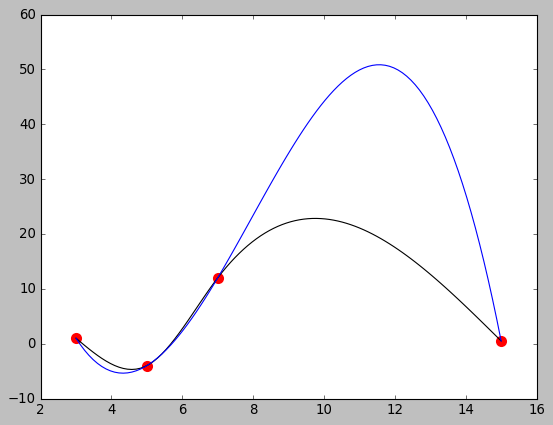

In [12]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(test_x_4nodes,test_y_4nodes,'ro',mec='None',ms=10)
ax.plot(test_x_4, test_y_4_natural, 'k-')
ax.plot(test_x_4, test_y_4_noknot, 'b-')

plt.show()

In [26]:
def mesa_interpolation(x, node_x, node_y):
    a0 = node_y[0]
    a1 = node_y[1]
    a2 = node_y[2]
    a3 = node_y[3]

    x0 = node_x[0]
    x1 = node_x[1]
    x2 = node_x[2]
    x3 = node_x[3]
    
    h = x1 - x0

    k = x - x1

    s_x = a1 + k*(-0.5*a0 + 0.5*a2) + k**2*(a0 - 2.5*a1 + 2*a2 - 0.5*a3) + k**3 * (-0.5*a0 + 1.5*a1 - 1.5*a2 + 0.5*a3)

    return s_x

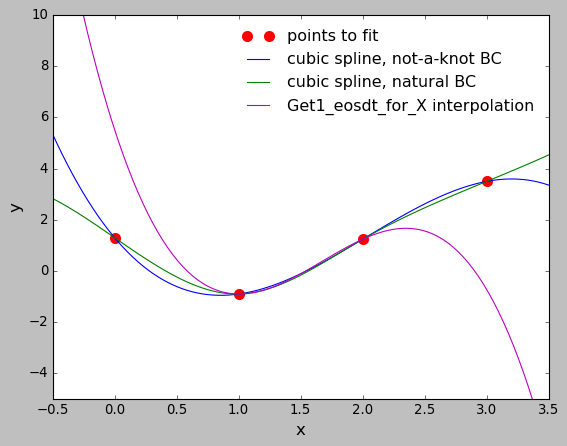

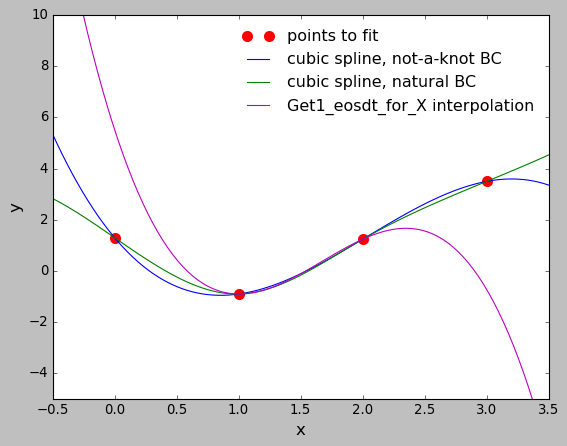

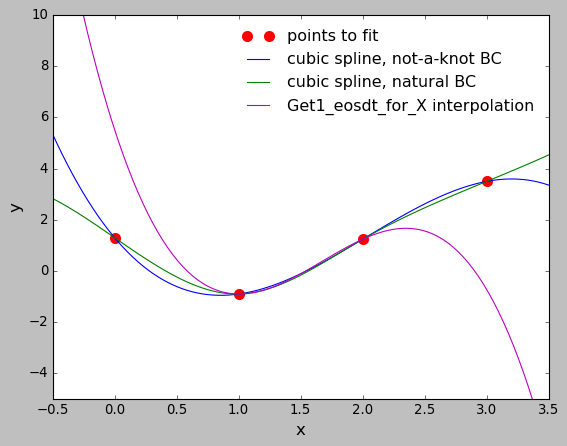

In [43]:
test_x_even = np.arange(0,4)
test_y_even = (1.3,-0.9,1.24,3.5)

test_y_spline_even = spline4_noknotBC_evenlyspaced(x=np.linspace(-0.5,3.5,100), node_x=test_x_even, node_y=test_y_even)
test_y_4_noknot = spline4_noknotBC(x=np.linspace(-0.5,3.5,100),node_x =test_x_even,node_y=test_y_even)
test_y_4_natural = spline4_naturalBC(x=np.linspace(-0.5,3.5,100),node_x =test_x_even,node_y=test_y_even)
test_MESA = mesa_interpolation(x=np.linspace(-0.5,3.5,100),node_x =test_x_even,node_y=test_y_even)

fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(test_x_even,test_y_even,'ro',mec='None',ms=10,label='points to fit')

#ax.plot(np.linspace(-0.5,3.5,100), test_y_spline_even, 'k-',label='cubic spline, not-a-knot BC')
ax.plot(np.linspace(-0.5,3.5,100), test_y_4_noknot, 'b-',label='cubic spline, not-a-knot BC')
ax.plot(np.linspace(-0.5,3.5,100), test_y_4_natural, 'g-',label='cubic spline, natural BC')
ax.plot(np.linspace(-0.5,3.5,100), test_MESA, 'm-', label='Get1_eosdt_for_X interpolation')

ax.set_xlim(-0.5,3.5)

ax.set_xlabel('x',fontsize=15)
ax.set_ylabel('y',fontsize=15)
ax.legend(loc='upper right',frameon=False)
ax.set_ylim(-5,10)

plt.show()
#plt.savefig("MESA_interpolation_comparison.pdf",bbox_inches='tight')